# Study on % of pid given in educaton

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('educ_uoe_fine06_linear.csv')
df.sample()

,DATAFLOW,LAST UPDATE,freq,unit,isced11,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
4955,ESTAT:EDUC_UOE_FINE06(1.0),07/08/25 23:00:00,Annual,Percentage of gross domestic product (GDP),Upper secondary and post-secondary non-tertiar...,Germany,2013,1.04,NaN,NaN


In [4]:
df["isced11"].value_counts()

isced11
Post-secondary non-tertiary education - general                                              372
Lower secondary education                                                                    364
Tertiary education (levels 5-8)                                                              363
Primary education                                                                            362
Upper secondary education                                                                    362
Upper secondary and post-secondary non-tertiary education (levels 3 and 4)                   359
Pre-primary education                                                                        357
Primary and lower secondary education (levels 1 and 2)                                       357
Post-secondary non-tertiary education - vocational                                           357
Post-secondary non-tertiary education                                                        356
Upper secondary educat

In [5]:
canonical_levels = [
    "Early childhood education",
    "Primary education",
    "Lower secondary education",
    "Upper secondary education",
    "Post-secondary non-tertiary education",
    "Tertiary education (levels 5-8)"
]

df_canonical = df[df["isced11"].isin(canonical_levels)]
total_by_country_year = (
    df_canonical.groupby(["geo", "TIME_PERIOD"])["OBS_VALUE"]
    .sum()
    .reset_index()
    .rename(columns={"OBS_VALUE": "education_pct_gdp_total"})
)

total_by_country_year.sort_values(by='education_pct_gdp_total')

,geo,TIME_PERIOD,education_pct_gdp_total
209,Liechtenstein,2018,0.00
212,Liechtenstein,2021,0.00
211,Liechtenstein,2020,0.00
210,Liechtenstein,2019,0.00
208,Liechtenstein,2017,0.00
...,...,...,...
167,Iceland,2020,8.14
265,Norway,2020,8.24
73,Denmark,2013,8.33
74,Denmark,2014,8.62


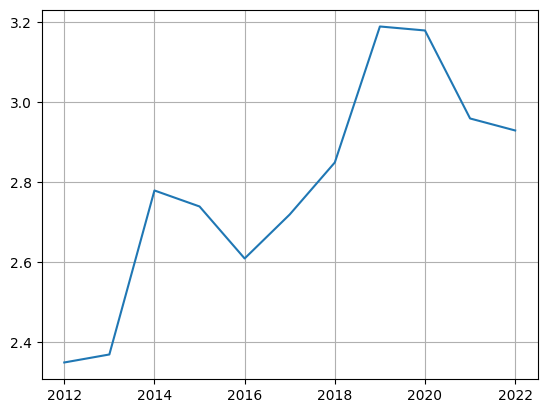

In [6]:
romania = total_by_country_year[total_by_country_year.geo == 'Romania']

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total)
plt.grid()

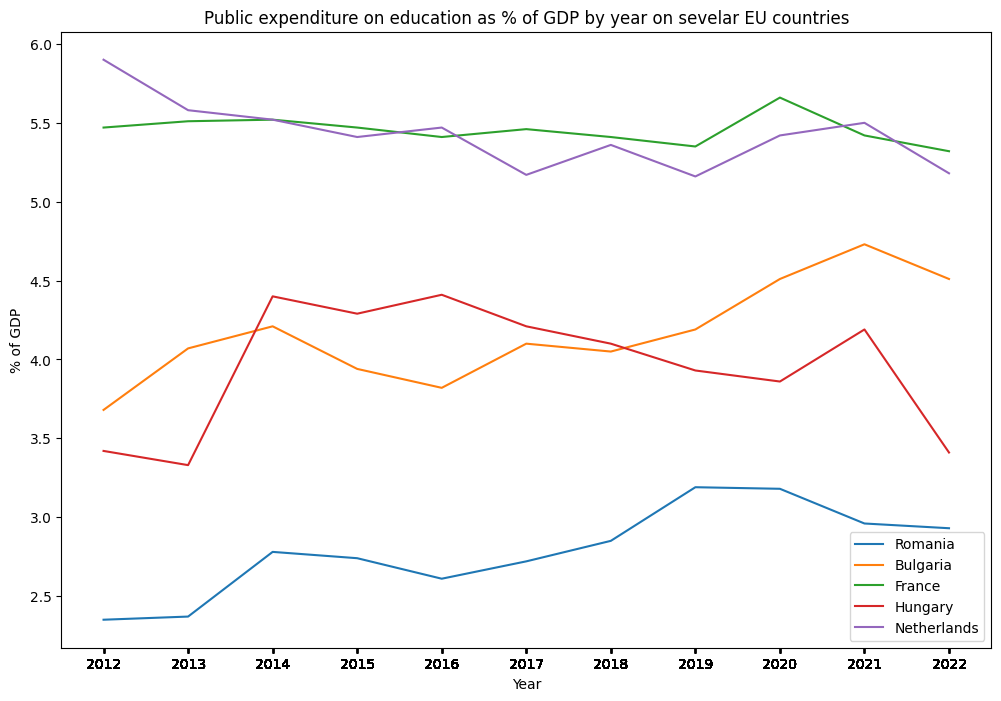

In [7]:
plt.figure(figsize=(12, 8))

plt.plot(romania.TIME_PERIOD, romania.education_pct_gdp_total, label='Romania')

#plot other contries total_by_country_year

Bulgaria = total_by_country_year[total_by_country_year.geo == 'Bulgaria']
plt.plot(Bulgaria.TIME_PERIOD, Bulgaria.education_pct_gdp_total, label='Bulgaria')

France = total_by_country_year[total_by_country_year.geo == 'France']
plt.plot(France.TIME_PERIOD, France.education_pct_gdp_total, label='France')

Hungary = total_by_country_year[total_by_country_year.geo == 'Hungary']
plt.plot(Hungary.TIME_PERIOD, Hungary.education_pct_gdp_total, label='Hungary')

Netherlands = total_by_country_year[total_by_country_year.geo == 'Netherlands']
plt.plot(Netherlands.TIME_PERIOD, Netherlands.education_pct_gdp_total, label='Netherlands')

plt.xticks(total_by_country_year.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on education as % of GDP by year on sevelar EU countries")
plt.legend()

This dataset goes only untill 2022, so we need to use another one

In [8]:
# link where to find the dataset: https://ec.europa.eu/eurostat/databrowser/view/gov_10a_exp/default/table

gov_spend = pd.read_csv('gov_10a_exp_linear.csv')
gov_spend.sample()

,DATAFLOW,LAST UPDATE,freq,unit,sector,cofog99,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
7967086,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Million euro,Local government,R&D Social protection,"Other current transfers,of which payable to su...",Spain,2023,0.0,p,NaN


In [9]:
gov_spend["sector"].value_counts()

sector
General government       7759224
Central government       6975353
Local government         6884504
Social security funds    6708606
State government         6404682
Name: count, dtype: int64

In [10]:
gov_spend["cofog99"].value_counts()

cofog99
Social protection                                                          495944
Health                                                                     494811
General public services                                                    494167
Recreation, culture and religion                                           493859
Education                                                                  493476
                                                                            ...  
Economic affairs n.e.c.                                                    424179
R&D Housing and community amenities                                        424109
Public debt transactions                                                   423885
Total                                                                      422353
Transfers of a general character between different levels of government    421850
Name: count, Length: 80, dtype: int64

In [11]:
gov_spend["unit"].value_counts()

unit
Million euro                                  9986157
Percentage of gross domestic product (GDP)    9986157
Million units of national currency            9986125
Percentage of total                           4773930
Name: count, dtype: int64

In [12]:
pib_procentage_edu = gov_spend[(gov_spend.cofog99 == 'Education') & (gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure')]
pib_procentage_edu

,DATAFLOW,LAST UPDATE,freq,unit,sector,cofog99,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
21617185,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Austria,1995,5.5,NaN,NaN
21617186,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Austria,1996,5.5,NaN,NaN
21617187,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Austria,1997,5.5,NaN,NaN
21617188,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Austria,1998,5.4,NaN,NaN
21617189,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Austria,1999,5.4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
21618138,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Slovakia,2019,4.4,p,NaN
21618139,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Slovakia,2020,4.7,p,NaN
21618140,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Slovakia,2021,4.6,p,NaN
21618141,ESTAT:GOV_10A_EXP(1.0),22/01/26 11:00:00,Annual,Percentage of gross domestic product (GDP),General government,Education,Total general government expenditure,Slovakia,2022,4.7,p,NaN


In [13]:
pib_procentage_edu.TIME_PERIOD.value_counts()

TIME_PERIOD
2010    33
2021    33
2019    33
2018    33
2017    33
2016    33
2015    33
2014    33
2013    33
2012    33
2011    33
2022    33
2009    33
2008    33
2007    33
2006    33
2005    33
2004    33
2003    33
2002    33
2001    33
2000    33
1999    33
1998    33
2023    33
2020    33
1995    32
1996    32
1997    32
2024     4
Name: count, dtype: int64

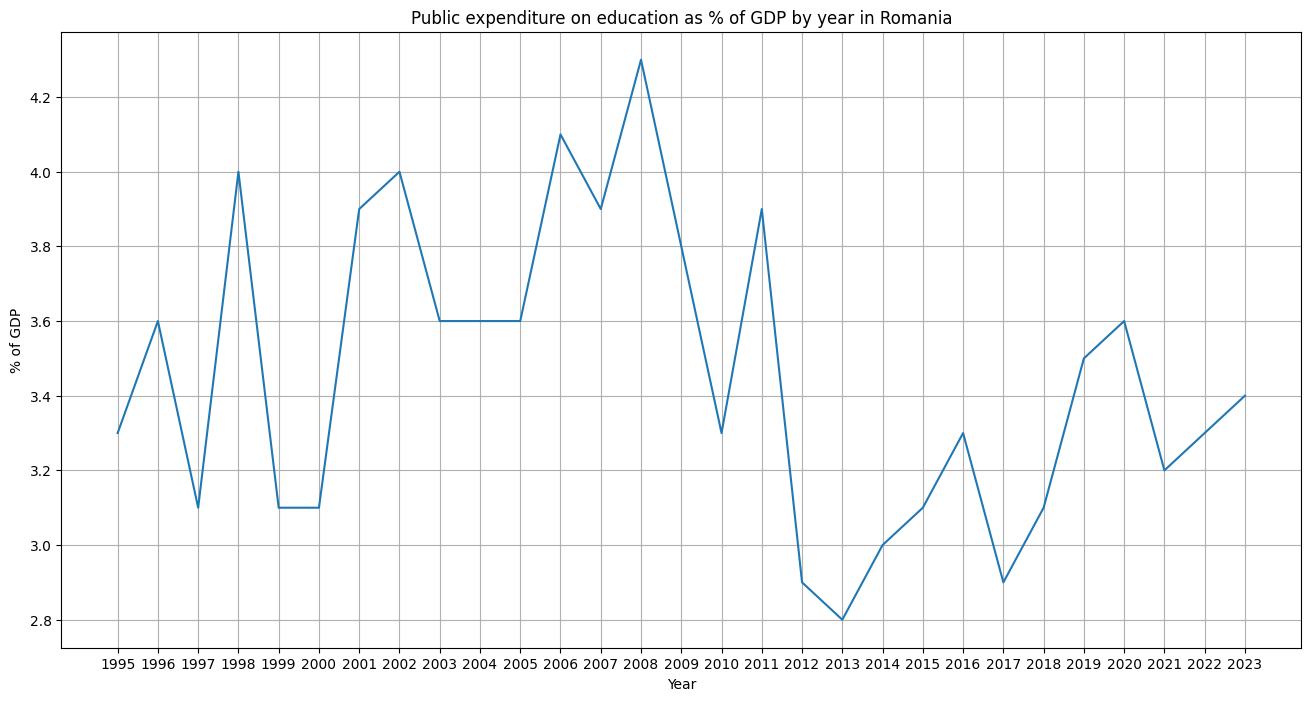

In [14]:
plt.figure(figsize=(16, 8))
romania = pib_procentage_edu[pib_procentage_edu.geo == 'Romania']

plt.plot(romania.TIME_PERIOD, romania.OBS_VALUE)

plt.xticks(romania.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on education as % of GDP by year in Romania")
plt.grid()

## let's take a look on health expenditure as well

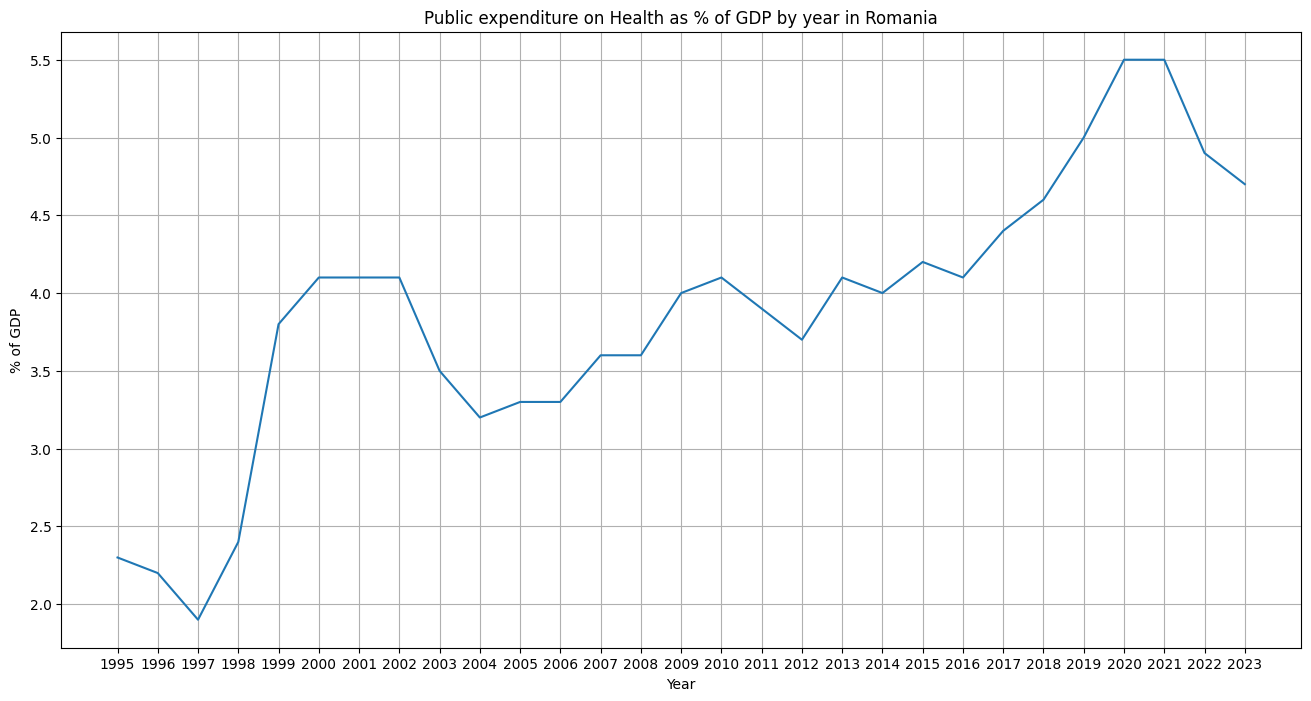

In [15]:
pib_procentage_H = gov_spend[(gov_spend.cofog99 == 'Health') & (gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure')]
plt.figure(figsize=(16, 8))
romania_H = pib_procentage_H[pib_procentage_H.geo == 'Romania']

plt.plot(romania_H.TIME_PERIOD, romania_H.OBS_VALUE)

plt.xticks(romania_H.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on Health as % of GDP by year in Romania")
plt.grid()

## let's compare all sectors

In [ ]:
# with open("sector_of_spending.txt", "a") as f:
#     for sector in gov_spend.cofog99.unique():
#         f.write(sector + '\n')

In [17]:
pib_procentage_by_sector_in_Romania = gov_spend[(gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure') & (gov_spend.geo == 'Romania')]

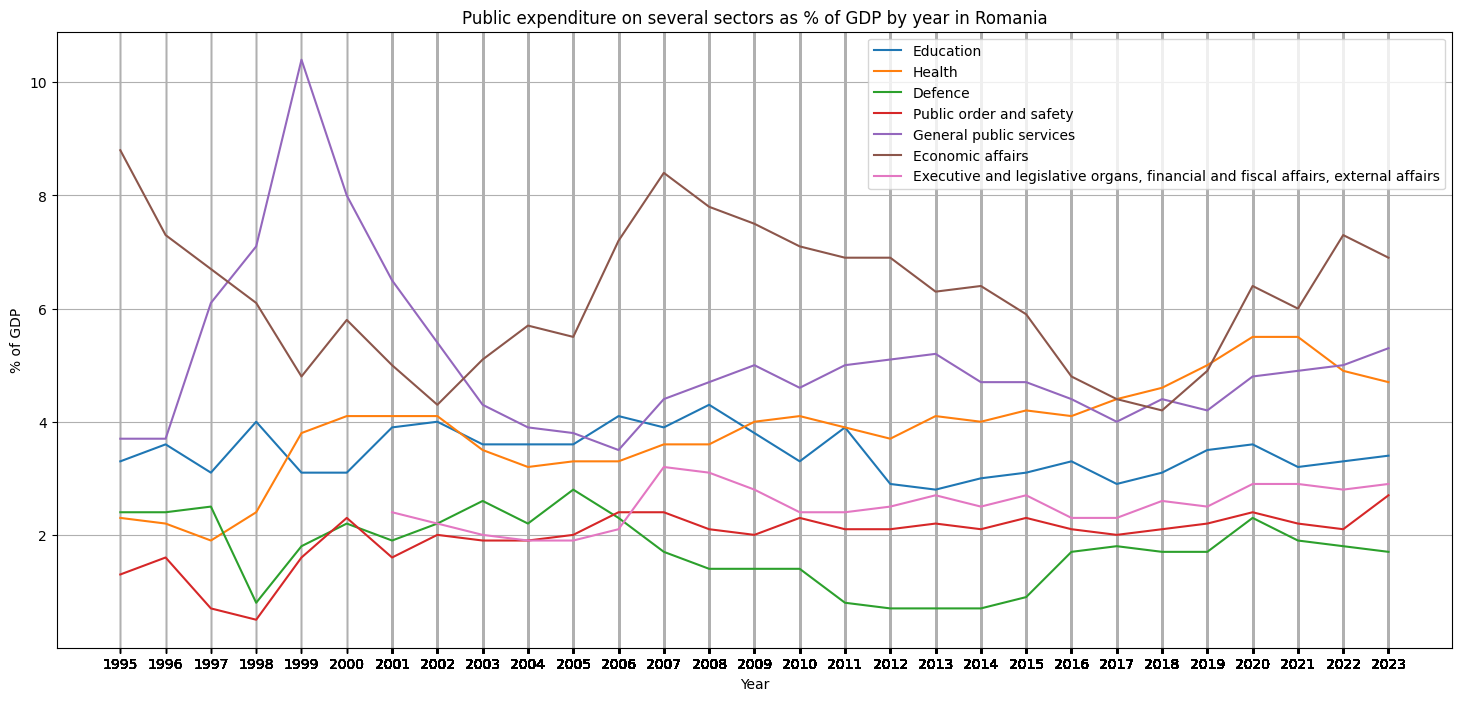

In [18]:
plt.figure(figsize=(18, 8))

# by sector I m refering to cofog99, Education/ Helth/religion/etc

top_sectors = [
    "Education",
    "Health",
    "Defence",
    "Public order and safety",
    "General public services",
    "Economic affairs",
    "Executive and legislative organs, financial and fiscal affairs, external affairs"
]
for sector in top_sectors:

    romania_sector = pib_procentage_by_sector_in_Romania[pib_procentage_by_sector_in_Romania.cofog99 == sector]
    plt.plot(romania_sector.TIME_PERIOD, romania_sector.OBS_VALUE, label = sector)

plt.xticks(pib_procentage_by_sector_in_Romania.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on several sectors as % of GDP by year in Romania")
plt.grid()
plt.legend()

In [19]:
pib_procentage_by_sector_in_France = gov_spend[(gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure') & (gov_spend.geo == 'France')]

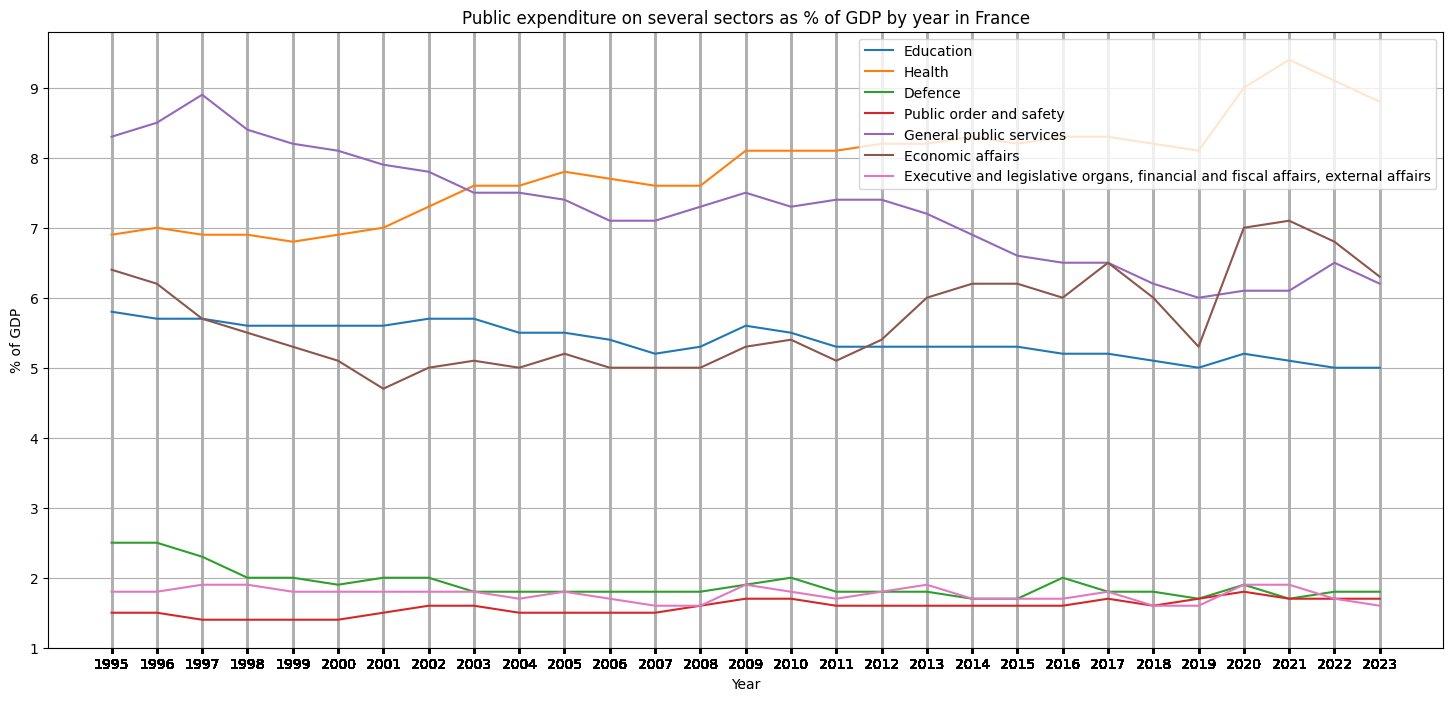

In [20]:
plt.figure(figsize=(18, 8))

# by sector I m refering to cofog99, Education/ Helth/religion/etc

top_sectors = [
    "Education",
    "Health",
    "Defence",
    "Public order and safety",
    "General public services",
    "Economic affairs",
    "Executive and legislative organs, financial and fiscal affairs, external affairs"
]
for sector in top_sectors:

    france_sector = pib_procentage_by_sector_in_France[pib_procentage_by_sector_in_France.cofog99 == sector]
    plt.plot(france_sector.TIME_PERIOD, france_sector.OBS_VALUE, label = sector)

plt.xticks(pib_procentage_by_sector_in_France.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on several sectors as % of GDP by year in France")
plt.grid()
plt.legend()

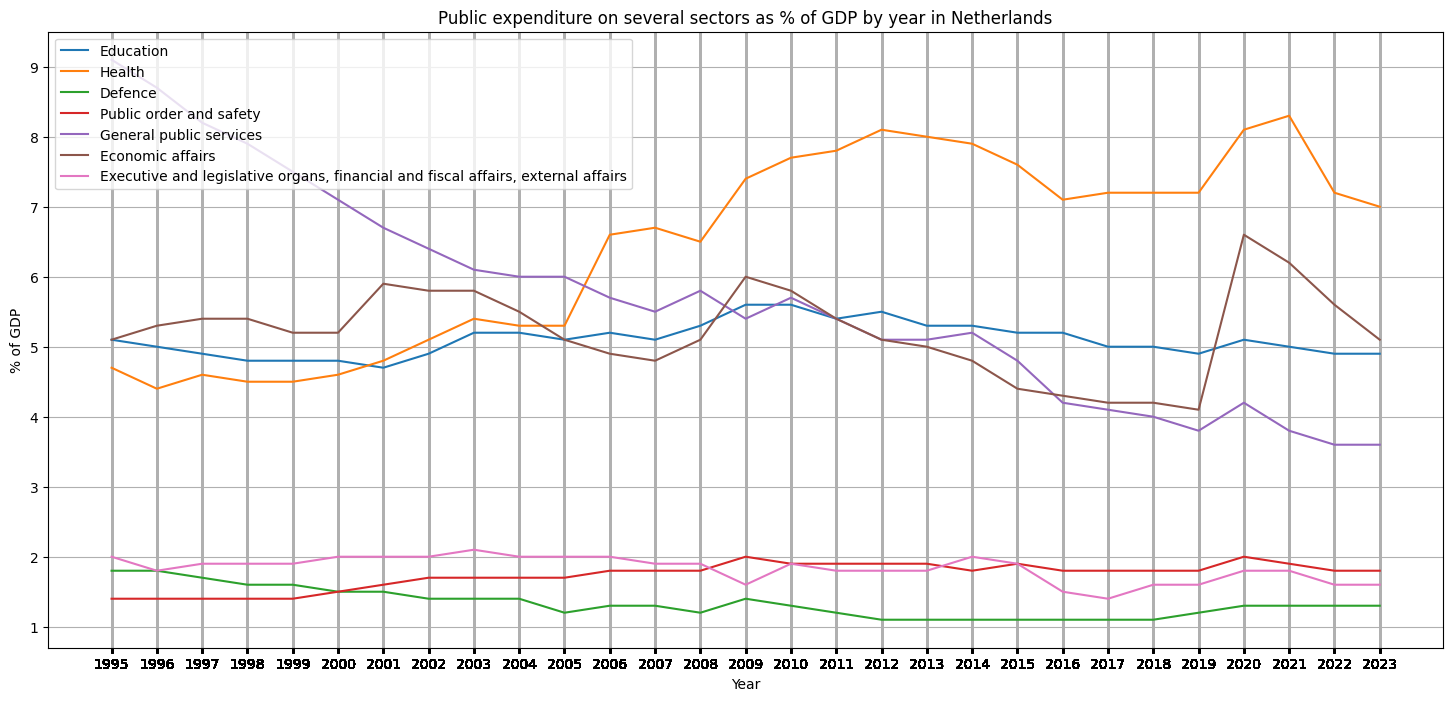

In [21]:
pib_procentage_by_sector_in_Netherlands = gov_spend[(gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure') & (gov_spend.geo == 'Netherlands')]

plt.figure(figsize=(18, 8))

# by sector I m refering to cofog99, Education/ Helth/religion/etc

top_sectors = [
    "Education",
    "Health",
    "Defence",
    "Public order and safety",
    "General public services",
    "Economic affairs",
    "Executive and legislative organs, financial and fiscal affairs, external affairs"
]
for sector in top_sectors:

    Netherlands_sector = pib_procentage_by_sector_in_Netherlands[pib_procentage_by_sector_in_Netherlands.cofog99 == sector]
    plt.plot(Netherlands_sector.TIME_PERIOD, Netherlands_sector.OBS_VALUE, label = sector)

plt.xticks(pib_procentage_by_sector_in_Netherlands.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on several sectors as % of GDP by year in Netherlands")
plt.grid()
plt.legend()

I want to check if we already have the EU median saved

In [22]:
gov_spend.geo.value_counts()

geo
Luxembourg                                   1358821
Hungary                                      1315839
Netherlands                                  1314733
Slovenia                                     1309440
Estonia                                      1309045
Norway                                       1279426
Switzerland                                  1267000
France                                       1254411
Cyprus                                       1242654
Czechia                                      1240093
Romania                                      1218020
Portugal                                     1183234
Bulgaria                                     1165968
Belgium                                      1162458
Iceland                                      1162325
Italy                                        1158915
Lithuania                                    1158875
Denmark                                      1156636
Spain                                     

We do, let's check the EU median

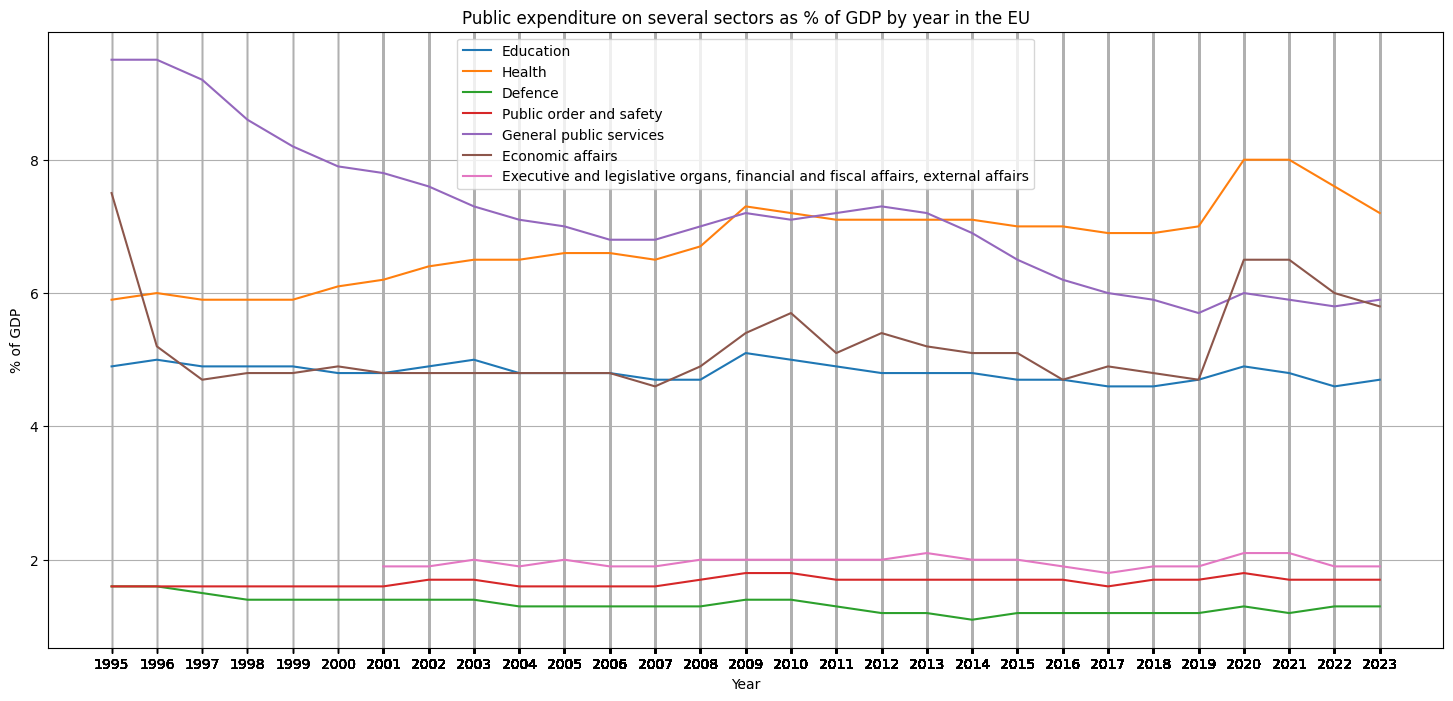

In [23]:
pib_procentage_by_sector_in_EU = gov_spend[(gov_spend.unit == 'Percentage of gross domestic product (GDP)') & (gov_spend.sector == 'General government') 
                               & (gov_spend.na_item == 'Total general government expenditure') & (gov_spend.geo == 'European Union - 27 countries (from 2020)')]

plt.figure(figsize=(18, 8))

# by sector I m refering to cofog99, Education/ Helth/religion/etc

top_sectors = [
    "Education",
    "Health",
    "Defence",
    "Public order and safety",
    "General public services",
    "Economic affairs",
    "Executive and legislative organs, financial and fiscal affairs, external affairs"
]
for sector in top_sectors:

    EU_sector = pib_procentage_by_sector_in_EU[pib_procentage_by_sector_in_EU.cofog99 == sector]
    plt.plot(EU_sector.TIME_PERIOD, EU_sector.OBS_VALUE, label = sector)

plt.xticks(pib_procentage_by_sector_in_EU.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.title("Public expenditure on several sectors as % of GDP by year in the EU")
plt.grid()
plt.legend()

## Let's see the difference better looking at only 1 year

In [ ]:
year = 2023

sectors = [
    "Education",
    "Health",
    "General public services",
    "Defence",
    "Public order and safety",
    "Economic affairs",
    "Executive and legislative organs, financial and fiscal affairs, external affairs"
]

df_2023 = gov_spend[
    (gov_spend.unit == "Percentage of gross domestic product (GDP)") &
    (gov_spend.sector == "General government") &
    (gov_spend.na_item == "Total general government expenditure") &
    (gov_spend.TIME_PERIOD == year) &
    (gov_spend.cofog99.isin(sectors)) &
    (gov_spend.geo.isin([
        "European Union - 27 countries (from 2020)",
        "Romania"
    ]))
]

import numpy as np

eu_values = []
ro_values = []

for s in sectors:
    eu_val = df_2023[
        (df_2023.cofog99 == s) &
        (df_2023.geo == "European Union - 27 countries (from 2020)")
    ]["OBS_VALUE"]

    ro_val = df_2023[
        (df_2023.cofog99 == s) &
        (df_2023.geo == "Romania")
    ]["OBS_VALUE"]

    eu_values.append(eu_val.values[0] if len(eu_val) > 0 else np.nan)
    ro_values.append(ro_val.values[0] if len(ro_val) > 0 else np.nan)

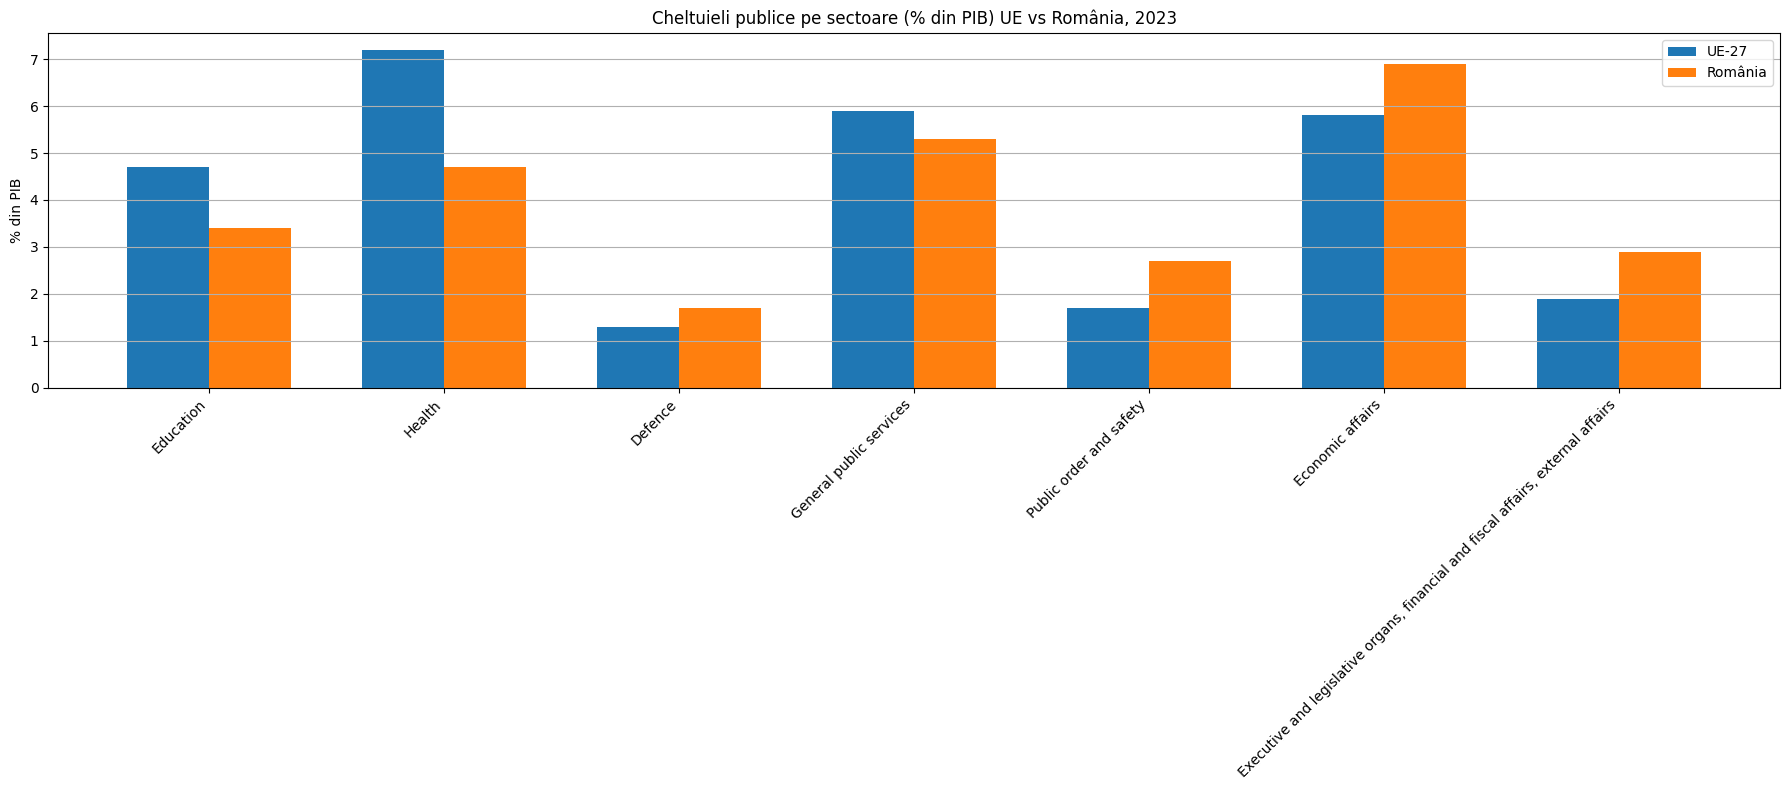

In [28]:
x = np.arange(len(sectors))
width = 0.35

plt.figure(figsize=(18, 8))

plt.bar(x - width/2, eu_values, width, label="UE-27")
plt.bar(x + width/2, ro_values, width, label="România")

plt.xticks(x, sectors, rotation=45, ha="right")
plt.ylabel("% din PIB")
plt.title("Cheltuieli publice pe sectoare (% din PIB) UE vs România, 2023")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()